In [ ]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_5_xgboost_distances/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1

cell_classifications = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## XGBoost distance assay — within-module grid cells

### What this analysis does

For every recording session that contains at least one grid module with ≥ 3 grid cells, we fit XGBoost models to predict each **target grid cell's** firing rate in VR using two covariate conditions:

| `covariate_type` | Covariates |
|---|---|
| `pos` | Position alone (baseline) |
| `pos+cell` | Position + a single within-module grid cell |

The baseline condition (`pos`) is fit once per target cell. The cell-inclusive condition tests **all unique ordered pairs** within the module: for every unordered pair (A, B) drawn from `itertools.combinations`, two models are fit — one predicting A using B as a covariate, and one predicting B using A as a covariate. The Euclidean anatomical distance is shared between both directions of a pair.

This lets us ask whether co-modular grid cell activity predicts a target cell's firing above and beyond position, and whether that predictive power depends on the anatomical distance between the two cells.

Only sessions where at least one grid module contains ≥ 3 GCs are loaded, avoiding unnecessary data I/O.

---

### Resulting dataframe — `results_df`

Each row is one XGBoost model fit. Columns:

| Column | Description |
|---|---|
| `mouse` | Mouse ID |
| `day` | Recording day |
| `grid_module` | Module index (0 = smallest field spacing) |
| `target_cluster_id` | Cluster ID of the cell being predicted |
| `cov_cluster_id` | Cluster ID of the single covariate grid cell (`NaN` for baseline) |
| `covariate_type` | One of `pos`, `pos+cell` |
| `pR2_cv` | Cross-validated Poisson pseudo-R² (mean across CV folds) |
| `euclidean_distance_um` | 3-D Euclidean distance (µm) between target and covariate cell in CCF space (`NaN` for baseline) |


In [5]:

from itertools import combinations

# XGBoost model parameters
nfilters = 5
history_length = 1000  # ms

xgb_history = MLencoding(
    tunemodel='xgboost',
    cov_history=True,
    spike_history=False,
    window=time_bs,
    n_filters=nfilters,
    max_time=history_length,
)

all_rows = []

cache_dir = '/Users/harryclark/Documents/spatial-manifolds/data/gc_module_xgboost_cache'
os.makedirs(cache_dir, exist_ok=True)

# Keep only sessions where at least one grid module contains ≥ 3 GCs
gc_module_counts = (
    cell_classifications[
        (cell_classifications['cell_type'] == 'GC') &
        (cell_classifications['grid_module'].notna())
    ]
    .groupby(['mouse', 'day', 'grid_module'])
    .size()
    .reset_index(name='n_gcs')
)
valid_sessions = (
    gc_module_counts[gc_module_counts['n_gcs'] >= 3]
    [['mouse', 'day']]
    .drop_duplicates()
)
print(f"{len(valid_sessions)} sessions have at least one module with ≥ 3 GCs.")

for _, sess_row in valid_sessions.iterrows():
    mouse_id = int(sess_row['mouse'])
    day_id   = int(sess_row['day'])
    print(f"\n=== M{mouse_id} D{day_id:02d} ===")

    # ── Session-level cache check: skip data loading if all GCs are cached ────
    _sess_gcs_check = cell_classifications[
        (cell_classifications['mouse'] == mouse_id) &
        (cell_classifications['day']   == day_id) &
        (cell_classifications['cell_type'] == 'GC') &
        (cell_classifications['grid_module'].notna())
    ]
    _gc_cache_files = {
        int(cid): os.path.join(cache_dir, f'M{mouse_id}_D{day_id:02d}_C{int(cid)}.csv')
        for cid in _sess_gcs_check['cluster_id']
    }
    if len(_gc_cache_files) > 0 and all(os.path.exists(f) for f in _gc_cache_files.values()):
        for cid, cache_file in _gc_cache_files.items():
            all_rows.extend(pd.read_csv(cache_file).to_dict('records'))
        print("  All GCs cached — skipping session load.")
        continue

    # Load VR spike trains and behaviour
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        mouse_id, day_id,
        apply_zscore=False, apply_guassian_filter=False,
        source_path=source_path,
    )

    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms'
    ).index[-1]
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')

    dt_in_time  = np.array(
        beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
        - ((beh['trial_number'][0] - 1) * tl)
    )
    pos_in_time = dt_in_time % tl

    if np.any(np.isnan(pos_in_time)):
        pos_in_time = pd.Series(dt_in_time).ffill().bfill().values % tl

    # GCs in this session with a module assignment
    sess_gcs = cell_classifications[
        (cell_classifications['mouse'] == mouse_id) &
        (cell_classifications['day']   == day_id) &
        (cell_classifications['cell_type'] == 'GC') &
        (cell_classifications['grid_module'].notna())
    ].copy()
    sess_gcs['cluster_id'] = sess_gcs['cluster_id'].astype(int)

    for module_id in sorted(sess_gcs['grid_module'].unique()):
        module_gcs  = sess_gcs[sess_gcs['grid_module'] == module_id].copy()
        module_cids = module_gcs['cluster_id'].values.astype(int)

        if len(module_cids) < 3:
            continue

        valid_cids = [c for c in module_cids if c in tcs_time]

        print(f"  Module {int(module_id)}: {len(module_cids)} GCs, "
              f"{len(list(combinations(valid_cids, 2)))} unique pairs")

        # Anatomical coordinates from the classification CSV
        coords = module_gcs.set_index('cluster_id')[['SC_x', 'SC_y', 'SC_z']]

        # ── Per-target-cell loop ───────────────────────────────────────────────
        for target_id in valid_cids:

            # ── GC-level cache check ───────────────────────────────────────────
            cache_file = os.path.join(cache_dir, f'M{mouse_id}_D{day_id:02d}_C{target_id}.csv')
            if os.path.exists(cache_file):
                print(f"    GC {target_id} (module {int(module_id)}): loading from cache.")
                all_rows.extend(pd.read_csv(cache_file).to_dict('records'))
                continue

            gc_rows = []

            y = np.array(tcs_time[target_id])
            T = len(y)
            pos = pos_in_time[:T]
            if len(pos) < T:
                pos = np.pad(pos, (0, T - len(pos)), mode='edge')

            # ── Baseline: position only ────────────────────────────────────────
            _, pR2_cv = xgb_history.fit_cv(pos[:, None], y, verbose=0, continuous_folds=True)
            gc_rows.append(dict(
                mouse=mouse_id, day=day_id, grid_module=int(module_id),
                target_cluster_id=target_id, cov_cluster_id=np.nan,
                covariate_type='pos',
                pR2_cv=float(np.nanmean(pR2_cv)),
                euclidean_distance_um=np.nan,
            ))

            # ── pos+cell: every other valid cell in module as covariate ────────
            for cov_id in valid_cids:
                if cov_id == target_id:
                    continue

                row_t = coords.loc[target_id]
                row_c = coords.loc[cov_id]
                dist = float(np.sqrt(
                    (float(row_t['SC_x']) - float(row_c['SC_x']))**2 +
                    (float(row_t['SC_y']) - float(row_c['SC_y']))**2 +
                    (float(row_t['SC_z']) - float(row_c['SC_z']))**2
                ))

                cov_spikes = np.array(tcs_time[cov_id])[:T]
                if len(cov_spikes) < T:
                    cov_spikes = np.pad(cov_spikes, (0, T - len(cov_spikes)), mode='constant')

                _, pR2_cv = xgb_history.fit_cv(
                    np.column_stack([pos, cov_spikes]), y, verbose=0, continuous_folds=True
                )
                gc_rows.append(dict(
                    mouse=mouse_id, day=day_id, grid_module=int(module_id),
                    target_cluster_id=target_id, cov_cluster_id=cov_id,
                    covariate_type='pos+cell',
                    pR2_cv=float(np.nanmean(pR2_cv)),
                    euclidean_distance_um=dist,
                ))

            # ── Save this GC's rows to cache ───────────────────────────────────
            pd.DataFrame(gc_rows).to_csv(cache_file, index=False)
            all_rows.extend(gc_rows)
            print(f"    GC {target_id} (module {int(module_id)}): done.")

        print(f"  Module {int(module_id)}: complete.")

results_df = pd.DataFrame(all_rows)
print(f"\nTotal rows collected: {len(results_df)}")
print(f"covariate_type counts:\n{results_df['covariate_type'].value_counts()}")
results_df.head(10)


28 sessions have at least one module with ≥ 3 GCs.

=== M20 D16 ===
  All GCs cached — skipping session load.

=== M20 D25 ===
  All GCs cached — skipping session load.

=== M21 D16 ===
  All GCs cached — skipping session load.

=== M21 D20 ===
  All GCs cached — skipping session load.

=== M21 D21 ===
  All GCs cached — skipping session load.

=== M21 D23 ===
  All GCs cached — skipping session load.

=== M21 D26 ===
  All GCs cached — skipping session load.

=== M25 D18 ===
  All GCs cached — skipping session load.

=== M25 D19 ===
  All GCs cached — skipping session load.

=== M25 D20 ===
  All GCs cached — skipping session load.

=== M25 D21 ===
  All GCs cached — skipping session load.

=== M25 D22 ===
  All GCs cached — skipping session load.

=== M25 D24 ===
  All GCs cached — skipping session load.

=== M25 D25 ===
  All GCs cached — skipping session load.

=== M26 D18 ===
  All GCs cached — skipping session load.

=== M26 D19 ===
  All GCs cached — skipping session load.

=== 

,mouse,day,grid_module,target_cluster_id,cov_cluster_id,covariate_type,pR2_cv,euclidean_distance_um
0,20,16,1,108,NaN,pos,0.006014,NaN
1,20,16,1,108,252.0,pos+cell,0.006389,524.781770
2,20,16,1,108,254.0,pos+cell,0.006143,503.567632
3,20,16,1,108,258.0,pos+cell,0.007623,473.531457
4,20,16,1,108,286.0,pos+cell,0.005209,697.072232
5,20,16,1,108,290.0,pos+cell,0.006431,676.893627
6,20,16,1,108,303.0,pos+cell,0.005895,638.854876
7,20,16,1,108,323.0,pos+cell,0.004717,574.139959
8,20,16,0,152,NaN,pos,0.003097,NaN
9,20,16,0,152,367.0,pos+cell,0.000505,331.080046


In [7]:
save_path = '/Users/harryclark/Documents/spatial-manifolds/data/gc_module_xgboost_distances.csv'
results_df.to_csv(save_path, index=False)
print(f"Saved {len(results_df)} rows → {save_path}")


Saved 8721 rows → /Users/harryclark/Documents/spatial-manifolds/data/gc_module_xgboost_distances.csv


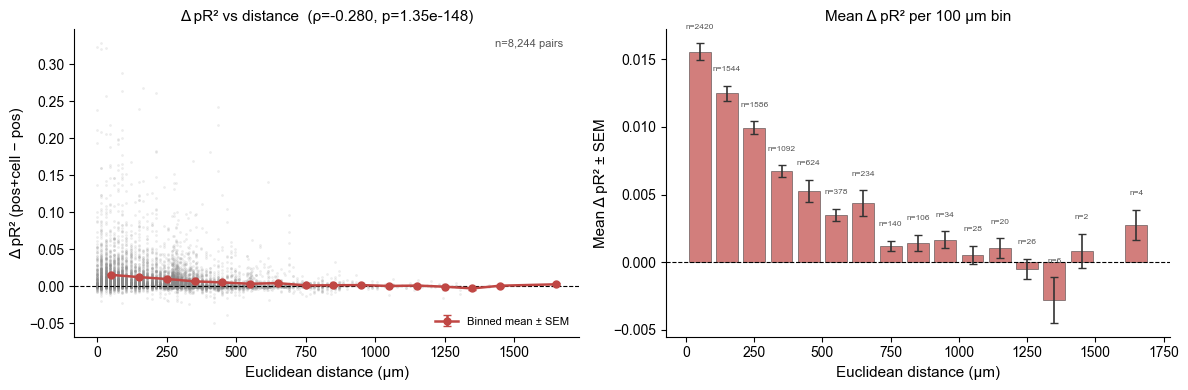

Spearman ρ=-0.280, p=1.35e-148  (n=8,244 cell pairs)


: 

In [ ]:

import seaborn as sns
from scipy import stats

# ── Compute Δ pR² = pos+cell − pos baseline ───────────────────────────────
_bl = (
    results_df[results_df['covariate_type'] == 'pos']
    [['mouse', 'day', 'target_cluster_id', 'pR2_cv']]
    .rename(columns={'pR2_cv': 'pR2_baseline'})
)
cov_df = results_df[results_df['covariate_type'] == 'pos+cell'].copy()
cov_df = cov_df.merge(_bl, on=['mouse', 'day', 'target_cluster_id'], how='left')
cov_df['delta_pR2'] = cov_df['pR2_cv'] - cov_df['pR2_baseline']
cov_df = cov_df.dropna(subset=['euclidean_distance_um', 'delta_pR2'])

# ── Distance bins (100 µm wide) ───────────────────────────────────────────
bin_edges  = np.arange(0, cov_df['euclidean_distance_um'].max() + 100, 100)
cov_df['dist_bin'] = pd.cut(cov_df['euclidean_distance_um'], bins=bin_edges, right=False)
bin_stats = (
    cov_df.groupby('dist_bin', observed=True)['delta_pR2']
    .agg(mean='mean', sem=lambda x: x.sem(), n='count')
    .reset_index()
)
bin_stats['bin_centre'] = bin_stats['dist_bin'].apply(lambda b: b.left + 50)

# ── Spearman correlation ───────────────────────────────────────────────────
r, p = stats.spearmanr(cov_df['euclidean_distance_um'], cov_df['delta_pR2'])
p_str = f'{p:.2e}' if p < 0.001 else f'{p:.3f}'

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: scatter + binned mean/SEM ─────────────────────────────────────
ax = axes[0]
ax.scatter(
    cov_df['euclidean_distance_um'], cov_df['delta_pR2'],
    color='#888888', alpha=0.15, s=4, linewidths=0, rasterized=True, zorder=1,
)
ax.errorbar(
    bin_stats['bin_centre'], bin_stats['mean'], yerr=bin_stats['sem'],
    fmt='o-', color='#c04744', linewidth=1.8, markersize=5,
    capsize=3, zorder=3, label='Binned mean ± SEM',
)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('Euclidean distance (µm)', fontsize=11)
ax.set_ylabel('Δ pR² (pos+cell − pos)', fontsize=11)
ax.set_title(f'Δ pR² vs distance  (ρ={r:.3f}, p={p_str})', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=8, frameon=False)
ax.text(0.97, 0.97, f'n={len(cov_df):,} pairs', transform=ax.transAxes,
        fontsize=8, ha='right', va='top', color='#555555')

# ── Right: binned mean ± SEM only, cleaner view ──────────────────────────
ax = axes[1]
ax.bar(
    bin_stats['bin_centre'], bin_stats['mean'],
    width=80, color='#c04744', alpha=0.7, edgecolor='#333333', linewidth=0.5,
)
ax.errorbar(
    bin_stats['bin_centre'], bin_stats['mean'], yerr=bin_stats['sem'],
    fmt='none', color='#333333', capsize=3, linewidth=1.2, zorder=3,
)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('Euclidean distance (µm)', fontsize=11)
ax.set_ylabel('Mean Δ pR² ± SEM', fontsize=11)
ax.set_title('Mean Δ pR² per 100 µm bin', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate n per bin
for _, row in bin_stats.iterrows():
    ax.text(row['bin_centre'], row['mean'] + row['sem'] + 0.001,
            f"n={int(row['n'])}", ha='center', va='bottom', fontsize=6, color='#555555')

fig.tight_layout()
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + 'gc_module_delta_pR2_vs_distance.pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f"Spearman ρ={r:.3f}, p={p_str}  (n={len(cov_df):,} cell pairs)")
